In [1]:
import pandas as pd
import sqlalchemy
import seaborn as sns
import matplotlib.pyplot as plt
import squarify
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import PercentFormatter
from datetime import timedelta


%matplotlib inline

In [2]:
fact_sales = pd.read_csv('fact_sales.csv')
dim_customers = pd.read_csv('dim_customers.csv')
dim_product = pd.read_csv('dim_product.csv')

In [3]:
df_customers = fact_sales.merge(
    dim_customers, 
    how='left', 
    on='customer_key'
)
df_product = fact_sales.merge(
    dim_product, 
    how='left', 
    on = 'product_key'
)
df_all = (
    fact_sales
    .merge(dim_customers, how='left', on='customer_key')
    .merge(dim_product, how='left', on='product_key')
)

**Time Series Analysis**

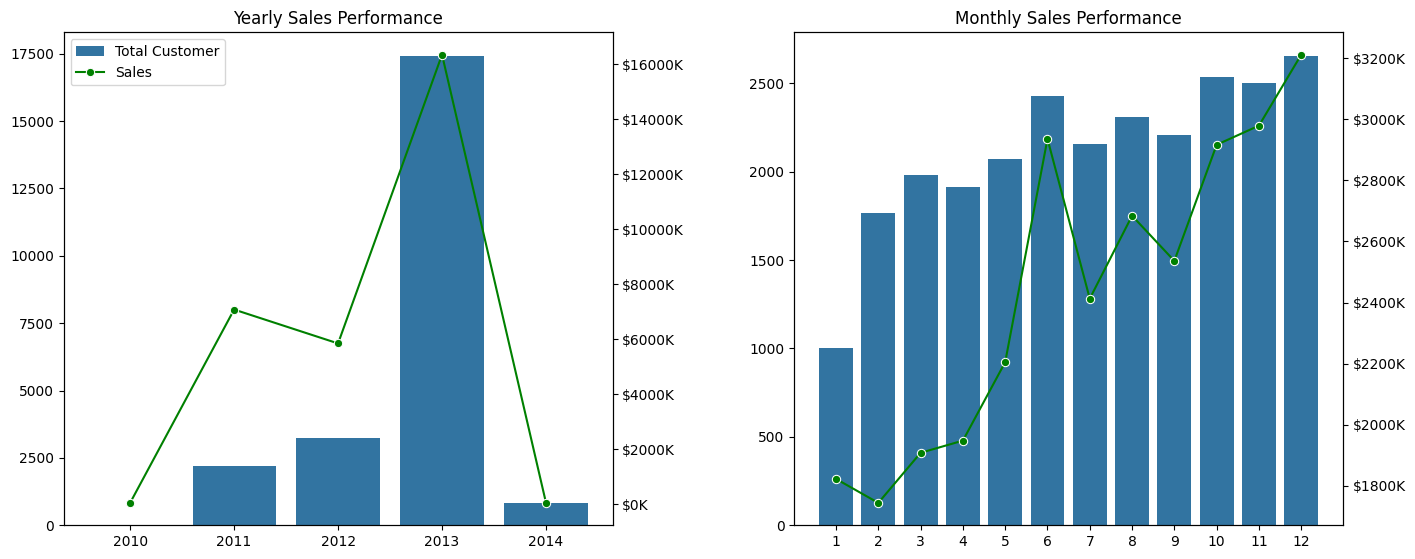

In [4]:
# Sales Performance Over Time
# ===== YEARLY =====
df_all['order_date']=pd.to_datetime(df_all['order_date'])
yearly_analysis = df_all.groupby(
    df_all['order_date'].dt.year
).agg({
    'sales': 'sum',
    'customer_key': 'nunique'
})

# ===== MONTHLY =====
# excluded 2014 data
excluded_2014 = df_all[df_all['order_date'].dt.year!=2014]
monthly_analysis = excluded_2014.groupby(
    excluded_2014['order_date'].dt.month
).agg({
    'sales':'sum',
    'customer_key' : 'nunique'
})

# ===== GRAPH =====
formatter = FuncFormatter(
    lambda x, pos: f'${x/1000:.0f}K')

fig, ax = plt.subplots(1,2,figsize=(16,8))
plt.tight_layout(pad = 10)
# Yearly Graph
ax1=ax[0]

ax1.set_title('Yearly Sales Performance')
sns.barplot(
    data = yearly_analysis,
    x = yearly_analysis.index,
    y = yearly_analysis.customer_key,
    ax=ax1,
    label = 'Total Customer',
)
ax1.set_xlabel('')
ax1.set_ylabel('')

ax2=ax1.twinx()
sns.lineplot(
    data = yearly_analysis,
    x = range(len(yearly_analysis.index)),
    y = yearly_analysis.sales,
    ax=ax2,
    color = 'g',
    marker = 'o',
    label = 'Sales',
    legend = False
)
ax2.set_ylabel('')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

# Combine legends
ax1.legend(
    h1 + h2,
    l1 + l2,
    loc='upper left'
)
ax2.yaxis.set_major_formatter(formatter);

# Monthly Graph
ax3=ax[1]
ax3.set_title('Monthly Sales Performance')
sns.barplot(
    data=monthly_analysis,
    x=monthly_analysis.index,
    y=monthly_analysis.customer_key,
    ax=ax3
)
ax3.set_xlabel('')
ax3.set_ylabel('')

ax4=ax3.twinx()

sns.lineplot(
    data=monthly_analysis,
    x = range(len(monthly_analysis.index)),
    y = monthly_analysis.sales,
    ax=ax4,
    color = 'g',
    marker = 'o'
)
ax4.set_xlabel('')
ax4.set_ylabel('')
ax4.yaxis.set_major_formatter(formatter);

**Key Observation - Yearly Sales Performance**:
- Sales experienced significant growth from 2011 to 2013. 2013 recorded the highest sales performance, reaching approximately *$16.34M*.
- The number of customers also increased substantially in 2013 *(17.427 of customers)* compared to previous years.
- The 2014 sales value appears inconsistent with the previous growth trend, suggesting that the 2014 data may be incomplete.

**Key Observation - Monthly Sales Performance**:
- Sales and total customers show an overall upward trend throughout the year.
- December achieved the highest sales, reaching approximately *$3.21M*, along with the highest number of customers at *2,656*.
- The increase in customer count was generally followed by an increase in sales, indicating a positive relationship between customer activity and revenue.

In [5]:
# why sales and customers in 2014 has surge decreased?

analysis_2014 = df_all[
    df_all['order_date'].dt.year == 2014
]

yearly_analysis = analysis_2014.groupby(
    analysis_2014['order_date'].dt.month
).agg({
    'sales': 'sum',
    'customer_key': 'nunique'
})
yearly_analysis


,sales,customer_key
order_date,,
1,45642,834


**Key Observation**
- The significant decline in sales and customer numbers in 2014 was initially identified as a potential business issue. However, further investigation revealed that the dataset only contained one month of records for 2014. Therefore, the 2014 data was excluded from time-series analysis, including year-over-year (YoY) and month-over-month (MoM) analysis, to ensure fair and accurate comparisons.

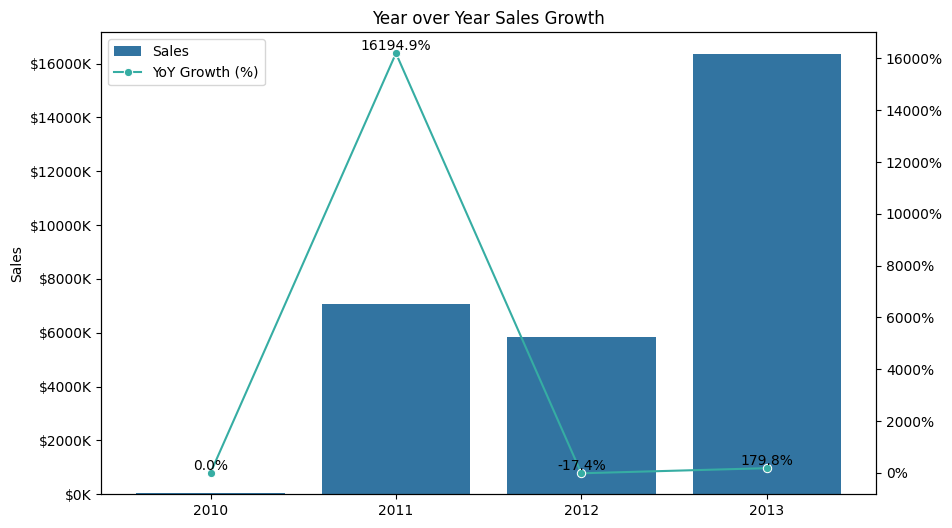

In [6]:
# Year-over-Year Analysis

YoY = df_all[df_all['order_date'].dt.year != 2014]

YoY = YoY.groupby(
    YoY['order_date'].dt.year
).agg({
    'sales': 'sum',
    'customer_key': 'nunique'
})

# Previous year sales
YoY['prev_sales'] = YoY['sales'].shift(1)

# YoY Growth
YoY['sales_yoy_pct'] = ((
    (YoY['sales'] - YoY['prev_sales'])
    / YoY['prev_sales']
) * 100).fillna(0)


# Graph

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=YoY,
    x=YoY.index,
    y='sales',
    ax=ax,
    label='Sales'
)

ax.set_title('Year over Year Sales Growth')
ax.set_xlabel('')
ax.set_ylabel('Sales')
ax.yaxis.set_major_formatter(formatter)

ax2 = ax.twinx()

sns.lineplot(
    data=YoY,
    x=range(len(YoY.index)),
    y='sales_yoy_pct',
    ax=ax2,
    marker='o',
    color='#36ADA3',
    label='YoY Growth (%)',
    legend = False
  
)

ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel('')
ax2.set_xlabel('')

# Combine legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax.legend(
    h1 + h2,
    l1 + l2,
    loc='upper left'
)

for i, value in enumerate(YoY['sales_yoy_pct']):
    ax2.text(
        i,                  # posisi x
        value,              # posisi y
        f'{value:.1f}%',    # format label
        ha='center',
        va='bottom'
    )

plt.show()

**Key Observation - Year-over-Year (YoY) Sales Growth**:
- Sales experienced extremely high growth in 2011, increasing by approximately *16,194%* compared to 2010.
- The unusually high YoY growth in 2011 was likely influenced by the very low sales baseline in 2010.
- Sales declined by approximately *17.4%* in 2012 compared to 2011, indicating a temporary slowdown in business performance.
- Despite the decline in sales during 2012, the number of customers continued to increase from *2,216* to *3,255*.
- Sales rebounded strongly in 2013, growing by approximately *179.8%* compared to 2012.
- 2013 recorded both the highest sales and highest customer count during the observed period.
- YoY performance shows fluctuating growth patterns rather than consistent annual growth.

In [7]:
# Analyze the detail of the products sales performance Year-over-Year

yearly_product_sales = df_all[
    df_all['order_date'].dt.year != 2014
]   

yearly_product_sales = yearly_product_sales.groupby([
    df_all['order_date'].dt.year.rename('year'),
    'product_name'
])['sales'].sum().reset_index()

# sort dulu
yearly_product_sales = yearly_product_sales.sort_values(
    by=['product_name', 'year']
)

# previous year sales per product
yearly_product_sales['py_sales'] = (
    yearly_product_sales
    .groupby('product_name')['sales']
    .shift(1)
)

# YoY
yearly_product_sales['YoY'] = (
    (
        (yearly_product_sales['sales'] -
         yearly_product_sales['py_sales'])
        / yearly_product_sales['py_sales']
    ) * 100
).round(2)

print(yearly_product_sales.to_string())

     year                     product_name    sales  py_sales        YoY
47   2012                     AWC Logo Cap       72       NaN        NaN
127  2013                     AWC Logo Cap    18891      72.0   26137.50
48   2012           All-Purpose Bike Stand      159       NaN        NaN
128  2013           All-Purpose Bike Stand    37683     159.0   23600.00
129  2013            Bike Wash - Dissolver     6960       NaN        NaN
130  2013                  Classic Vest- L    11968       NaN        NaN
131  2013                  Classic Vest- M    11840       NaN        NaN
49   2012                  Classic Vest- S       64       NaN        NaN
132  2013                  Classic Vest- S    10368      64.0   16100.00
50   2012            Fender Set - Mountain      110       NaN        NaN
133  2013            Fender Set - Mountain    44484     110.0   40340.00
51   2012                 HL Mountain Tire      140       NaN        NaN
134  2013                 HL Mountain Tire    46935

**Key Observations - Product-Level YoY Sales Performance**
- products such as Half-Finger Gloves *(24 to 11,376)*, Water Bottle - 30 oz.*(90 to 20,425)*, and Patch Kit/8 Patches *(8 to 6,048)* showed exceptionally high YoY growth percentages.
- A few products experienced negative growth in 2013: Road-250 Red-58 declined by *14.90%*, Road-250 Black-52 declined by *7.00%*
- Road-150 Red variants were among the strongest contributors in 2011, with Road-150 Red-48 reaching *1.19M* sales.
- Products under the *Mountain, Road, and Touring series* dominated overall sales performance across multiple years.
- Product sales became more diversified in 2013, with multiple product categories contributing significant revenue growth

**Segmentation Analysis**

Group customers into three segments based on their spending behavior:
- VIP: Customers with at least 12 months of history and spending more than €5,000.
- Regular: Customers with at least 12 months of history but spending €5,000 or less.
- New: Customers with a lifespan less than 12 months.
And find the total number of customers by each group

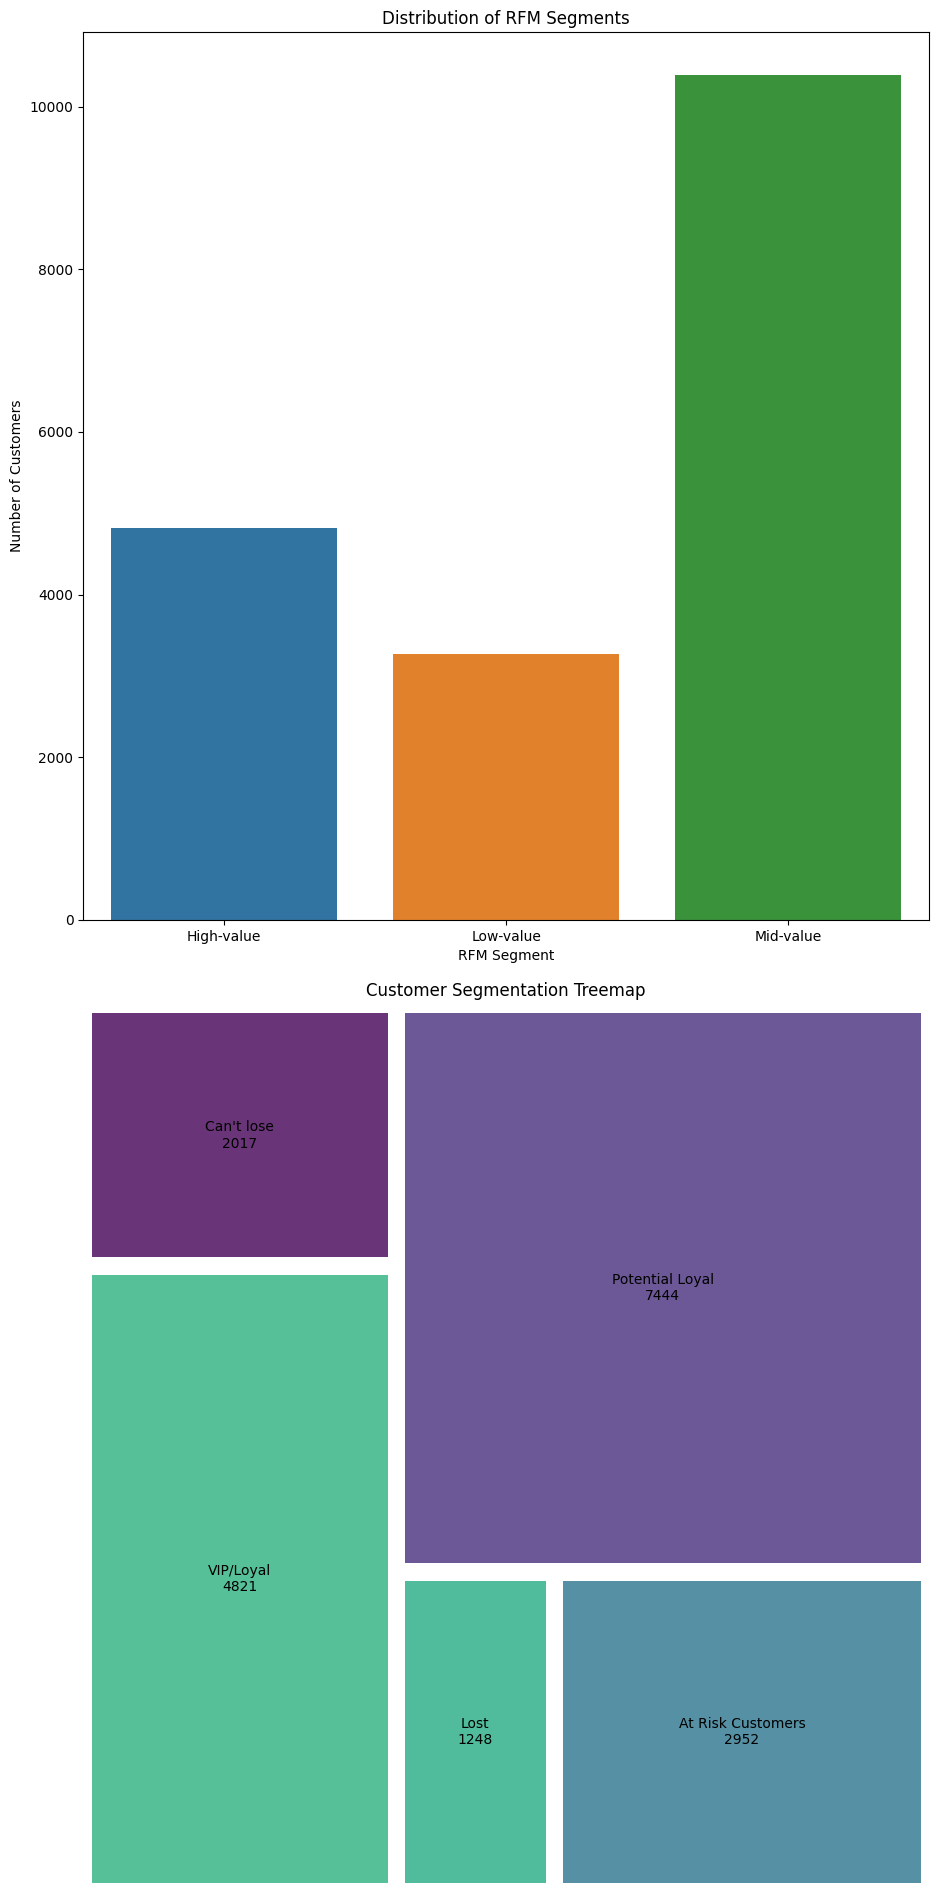

In [8]:
#RFM
reference_date = df_all['order_date'].max() + timedelta(days=1)
rfm = df_all.groupby('customer_key').agg({
    'order_date' : lambda x:(reference_date-x.max()).days,
    'order_number' : 'nunique',
    'sales' : 'sum'
})
rfm.rename(columns={'order_date':'Recency','order_number':'Frequency','sales':'Monetary'}, inplace=True)

#Scoring
quantile = rfm.quantile([0.25,0.50,0.75])

def Rscore(x,p,d):
    if p =='Recency':
        if x<= d[p][0.25]:
            return 4
        elif x<= d[p][0.50]:
            return 3
        elif x<=d[p][0.75]:
            return 2
        else :
            return 1
    else :
        if x<= d[p][0.25]:
            return 1
        elif x<= d[p][0.50]:
            return 2
        elif x<=d[p][0.75]:
            return 3
        else :
            return 4
        
rfm['R'] = rfm['Recency'].apply(Rscore, args=('Recency',quantile))
rfm['F'] = rfm['Frequency'].apply(Rscore, args=('Frequency',quantile))
rfm['M'] = rfm['Monetary'].apply(Rscore, args=('Monetary',quantile))
rfm['RFM_Segment'] = rfm['R'].astype(str)+ rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_score'] = rfm[['R','F','M']].sum(axis=1)

# Segmentation
segment_label=['Low-value','Mid-value','High-value']
def assign_segment(score):
    if score < 5 :
        return 'Low-value'
    elif score < 9 :
        return 'Mid-value'
    else :
        return 'High-value'
rfm['RFM_segment_label'] = rfm['RFM_score'].apply(assign_segment)
segment_counts = rfm['RFM_segment_label'].value_counts().reset_index().sort_values('RFM_segment_label')

# 
rfm['RFM_Customer_Segmentation'] = ''
rfm.loc[(rfm['RFM_score']>=9),'RFM_Customer_Segmentation']='VIP/Loyal'
rfm.loc[(rfm['RFM_score']>=6) & (rfm['RFM_score']<9) , 'RFM_Customer_Segmentation'] = 'Potential Loyal'
rfm.loc[(rfm['RFM_score']>=5) & (rfm['RFM_score']<6) , 'RFM_Customer_Segmentation'] = 'At Risk Customers'
rfm.loc[(rfm['RFM_score']>=4) & (rfm['RFM_score']<5) , 'RFM_Customer_Segmentation'] = "Can't lose"
rfm.loc[(rfm['RFM_score']>=3) & (rfm['RFM_score']<4) , 'RFM_Customer_Segmentation'] = 'Lost'
segment_product_counts = rfm.groupby(['RFM_segment_label','RFM_Customer_Segmentation']).size().reset_index(name='count')
# GRAPH
fig, ax = plt.subplots(2,1,figsize=(10,20))
plt.tight_layout(pad=4)

ax1 = ax[0]
sns.barplot(
    data = segment_counts,
    x = 'RFM_segment_label',
    y = 'count',
    hue = 'RFM_segment_label',
    ax=ax1
)
ax1.set_xlabel('RFM Segment')
ax1.set_ylabel('Number of Customers')
ax1.set_title('Distribution of RFM Segments')

# TREEMAP LABEL
labels = [
    f"{segment}\n{count}"
    for segment, count in zip(
        segment_product_counts['RFM_Customer_Segmentation'],
        segment_product_counts['count']
    )
]

# TREEMAP
ax2 = ax[1]

squarify.plot(
    sizes=segment_product_counts['count'],
    label=labels,
    pad=True,
    alpha=0.8,
    ax=ax2
)

ax2.set_title('Customer Segmentation Treemap')
ax2.axis('off')

plt.show()


**Key Observations — RFM Customer Segmentation**:
- The majority of customers belong to the Mid-value segment, accounting for *10,396 customers*. Within the Mid-value segment: Potential Loyal customers represent the largest group with *7,444 customers* and At Risk Customers account for *2,952 customers*
- The High-value segment contains *4,821 customers*, all categorized as VIP/Loyal customers.
- The Low-value segment consists of *3,265 customers* in total: *2,017 customers* are classified as Can't Lose and *1,248 customers* are classified as Lost
- The number of VIP/Loyal customers *(4,821)* is substantially higher than the number of Lost customers *(1,248)*.
- The presence of *2,952* At Risk Customers indicates a considerable portion of customers showing declining engagement or purchasing activity.
- The combined number of Can't Lose and At Risk customers reaches *4,969 customers*, representing a significant customer group with potential retention concerns.